<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_035_parameters_vs_hyperparameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 35/365 — Parameters vs Hyperparameters
## What does the model learn, and what do we choose?

- **Parameters** are learned from training data.
- **Hyperparameters** are settings chosen before or around training.

Today we use Ridge Regression on the real scikit-learn Diabetes dataset to make the difference visible.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score


## 1. Load the real dataset


In [2]:
data = load_diabetes(as_frame=True)
X = data.data.copy()
y = data.target.copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print('Dataset shape:', X.shape)


Dataset shape: (442, 10)


## 2. Hyperparameter: `alpha`

In Ridge Regression, `alpha` controls L2 regularization strength. We provide it to the model, so it is a **hyperparameter**.


In [3]:
chosen_alpha = 10
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=chosen_alpha))
])
pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)
print('Chosen alpha:', chosen_alpha)
print('Test RMSE:', round(rmse, 2))
print('Test R2:', round(r2, 3))


Chosen alpha: 10
Test RMSE: 53.63
Test R2: 0.457


## 3. Parameters learned from data

After `fit()`, Ridge learns coefficients and an intercept. Those are **parameters**.


In [4]:
ridge = pipeline.named_steps['model']
params = pd.DataFrame({'Feature': X.columns, 'Learned Coefficient': ridge.coef_})
print('Learned intercept:', round(ridge.intercept_, 3))
display(params.round(3))


Learned intercept: 153.737


,Feature,Learned Coefficient
0,age,1.931
1,sex,-11.028
2,bmi,25.606
3,bp,16.304
4,s1,-12.934
5,s2,0.538
6,s3,-6.125
7,s4,8.569
8,s5,22.749
9,s6,2.918


## 4. Change only the hyperparameter


In [5]:
alphas = [0.01, 0.1, 1, 10, 100, 1000]
rows = []
for alpha in alphas:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(X_train, y_train)
    p = model.predict(X_test)
    rows.append({
        'Alpha': alpha,
        'Test RMSE': np.sqrt(mean_squared_error(y_test, p)),
        'Test R2': r2_score(y_test, p),
        'Coefficient Magnitude': np.linalg.norm(model.named_steps['ridge'].coef_)
    })
results = pd.DataFrame(rows)
display(results.round(4))


,Alpha,Test RMSE,Test R2,Coefficient Magnitude
0,0.01,53.8523,0.4526,71.4836
1,0.10,53.8429,0.4528,70.2143
2,1.00,53.7775,0.4541,60.9088
3,10.00,53.6263,0.4572,43.0280
4,100.00,53.4624,0.4605,34.2828
5,1000.00,58.7513,0.3485,15.8844


## 5. Visualize how a hyperparameter changes learned parameters


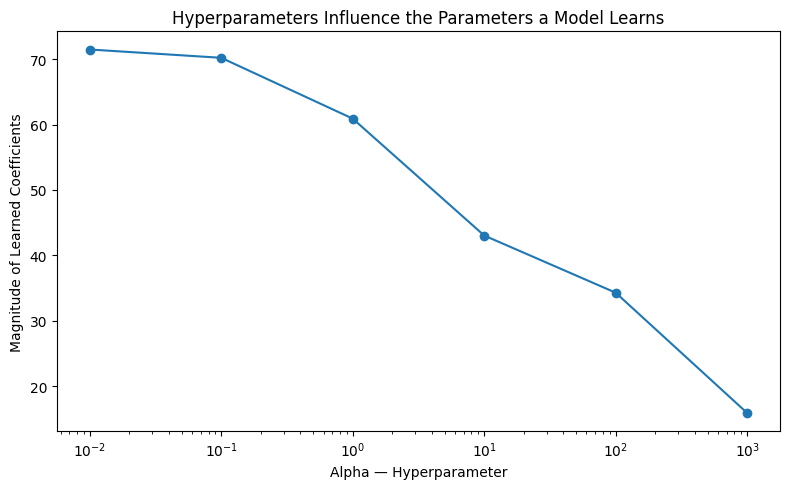

In [6]:
plt.figure(figsize=(8,5))
plt.plot(results['Alpha'], results['Coefficient Magnitude'], marker='o')
plt.xscale('log')
plt.xlabel('Alpha — Hyperparameter')
plt.ylabel('Magnitude of Learned Coefficients')
plt.title('Hyperparameters Influence the Parameters a Model Learns')
plt.tight_layout()
plt.show()


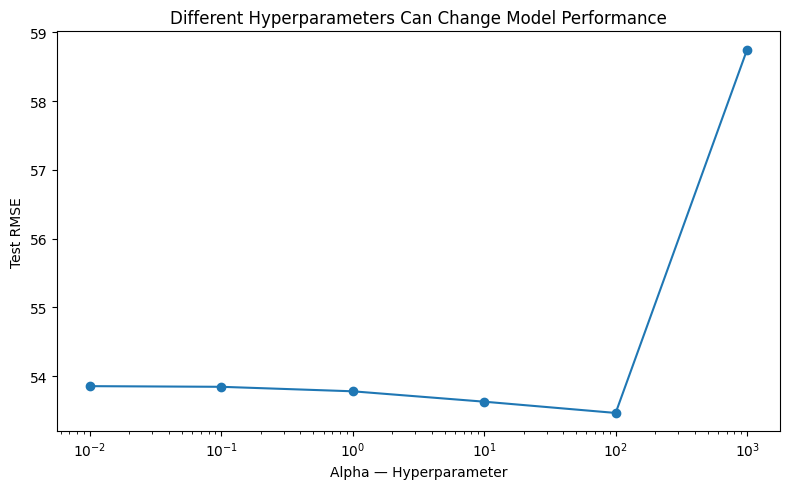

In [7]:
plt.figure(figsize=(8,5))
plt.plot(results['Alpha'], results['Test RMSE'], marker='o')
plt.xscale('log')
plt.xlabel('Alpha — Hyperparameter')
plt.ylabel('Test RMSE')
plt.title('Different Hyperparameters Can Change Model Performance')
plt.tight_layout()
plt.show()


## What does this teach?

- Parameters are learned from data.
- Hyperparameters are chosen settings that influence training.
- Ridge coefficients and intercept are parameters.
- Ridge `alpha` is a hyperparameter.
- Changing `alpha` changes the learned coefficients and can change performance.
- Do not choose hyperparameters using the final test set.

> Next: how do we choose hyperparameters systematically instead of guessing?


## References

- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
- https://scikit-learn.org/stable/model_selection.html
- https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html
